# CWT transferability: ResNet18 and ViT-tiny on CIFAR-10

Lightning/Kaggle experiment comparing MI-FGSM with CWT-MI-FGSM under identical epsilon and iteration count.

In [1]:
!pip install lightning timm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 37.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import copy
import csv
import hashlib
import json
import random
import time

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
L.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)

CIFAR_INPUT = Path('/kaggle/input/datasets/oxcdcd/cifar10/cifar10')
DOWNLOAD_ROOT = Path('/kaggle/working/cifar10_data')
WEIGHTS_DIR = Path('/kaggle/input/datasets/notquartzz/weights-aa')
RESNET_WEIGHTS = WEIGHTS_DIR / 'resnet18_cifar10.pth'
VIT_WEIGHTS = WEIGHTS_DIR / 'vit_t_cifar10.pth'
OUTPUT_DIR = Path('/kaggle/working/cwt_transferability')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
ATTACK_BATCH_SIZE = 16
NUM_WORKERS = 2
MAX_SAMPLES = 500
EPSILON = 16 / 255
STEPS = 10
MOMENTUM_DECAY = 1.0
COPY_CHUNK = 4
CWT_COPIES = 20
CIFAR10_CLASSES = ('airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck')
print('Device:', DEVICE)


Seed set to 42


Device: cuda


## Lightning DataModule

In [3]:
class CIFAR10DataModule(L.LightningDataModule):
    def __init__(self, input_path=CIFAR_INPUT, download_root=DOWNLOAD_ROOT,
                 batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
        super().__init__()
        self.input_path = Path(input_path)
        self.download_root = Path(download_root)
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.transform = transforms.ToTensor()

    @property
    def imagefolder_test(self):
        return self.input_path / 'test'

    def prepare_data(self):
        if self.imagefolder_test.is_dir():
            return
        self.download_root.mkdir(parents=True, exist_ok=True)
        datasets.CIFAR10(self.download_root, train=False, download=True)

    def setup(self, stage=None):
        if self.imagefolder_test.is_dir():
            self.test_set = datasets.ImageFolder(self.imagefolder_test, transform=self.transform)
            folder_classes = tuple(self.test_set.classes)
            numeric_classes = tuple(str(index) for index in range(10))
            if folder_classes not in (CIFAR10_CLASSES, numeric_classes):
                raise ValueError(f'Unexpected ImageFolder classes: {folder_classes}')
        else:
            self.test_set = datasets.CIFAR10(
                self.download_root, train=False, download=False, transform=self.transform
            )

    def test_dataloader(self):
        return DataLoader(
            self.test_set, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=torch.cuda.is_available(),
            persistent_workers=self.num_workers > 0, drop_last=False,
        )


dm = CIFAR10DataModule()
dm.prepare_data()
dm.setup('test')
sample_x, sample_y = next(iter(dm.test_dataloader()))
assert sample_x.shape[1:] == (3, 32, 32)
assert 0 <= sample_x.min() <= sample_x.max() <= 1
print('Test images:', len(dm.test_set))


Test images: 10000


## Lightning models and strict checkpoint loading

In [4]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, -1, 1, 1))
        self.register_buffer('std', torch.tensor(std).view(1, -1, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class ResNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.normalize = Normalize((0.4914,0.4822,0.4465), (0.2470,0.2435,0.2616))
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 2, 1)
        self.layer2 = self._make_layer(128, 2, 2)
        self.layer3 = self._make_layer(256, 2, 2)
        self.layer4 = self._make_layer(512, 2, 2)
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, planes, blocks, first_stride):
        layers = []
        for stride in [first_stride] + [1] * (blocks - 1):
            layers.append(BasicBlock(self.in_planes, planes, stride))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.normalize(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)
        return self.linear(x)


class NormalizedModel(nn.Module):
    def __init__(self, backbone, mean, std):
        super().__init__()
        self.normalize = Normalize(mean, std)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(self.normalize(x))


class AttackClassifier(L.LightningModule):
    def __init__(self, model, model_name):
        super().__init__()
        self.model = model
        self.model_name = model_name

    def forward(self, x):
        return self.model(x)

    def test_step(self, batch, batch_idx):
        images, labels = batch
        accuracy = (self(images).argmax(1) == labels).float().mean()
        self.log(f'{self.model_name}_test_acc', accuracy, on_epoch=True, batch_size=labels.size(0))


def checkpoint_state(path):
    if not path.is_file():
        available = sorted(WEIGHTS_DIR.rglob('*')) if WEIGHTS_DIR.exists() else []
        raise FileNotFoundError(f'Missing checkpoint {path}. Available: {available}')
    checkpoint = torch.load(path, map_location='cpu', weights_only=True)
    state = checkpoint.get('state_dict', checkpoint.get('model_state_dict', checkpoint))
    return {key.removeprefix('module.').removeprefix('model.'): value for key, value in state.items()}


resnet_raw = ResNetCIFAR()
resnet_raw.load_state_dict(checkpoint_state(RESNET_WEIGHTS), strict=True)
vit_raw = timm.create_model(
    'vit_tiny_patch16_224', pretrained=False, num_classes=10,
    in_chans=3, img_size=32, patch_size=4,
)
vit_state = {
    key: value for key, value in checkpoint_state(VIT_WEIGHTS).items()
    if key not in {'normalize.mean', 'normalize.std'}
}
vit_raw.load_state_dict(vit_state, strict=True)
vit_normalized = NormalizedModel(
    vit_raw, mean=(0.4914,0.4822,0.4465), std=(0.2023,0.1994,0.2010)
)

resnet_module = AttackClassifier(resnet_raw, 'resnet18')
vit_module = AttackClassifier(vit_normalized, 'vit_tiny')
models_by_name = {'resnet18': resnet_module, 'vit_tiny': vit_module}
for model in models_by_name.values():
    model.to(DEVICE).eval().requires_grad_(False)
with torch.inference_mode():
    for name, model in models_by_name.items():
        assert model(sample_x[:2].to(DEVICE)).shape == (2, 10), name
print('Both checkpoints loaded strictly')


Both checkpoints loaded strictly


## Lightning smoke test

In [5]:
for model_name, model in models_by_name.items():
    trainer = L.Trainer(
        fast_dev_run=True, accelerator='auto', devices=1,
        logger=False, enable_checkpointing=False, enable_model_summary=False,
    )
    trainer.test(model, datamodule=dm, verbose=False)
    model.to(DEVICE).eval().requires_grad_(False)
    print('Lightning smoke test passed:', model_name)
del trainer


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Lightning smoke test passed: resnet18


Output()

Lightning smoke test passed: vit_tiny


## Reusable CWT and attack API

In [6]:
"""Component-Wise Transformation for transferable adversarial attacks."""

from __future__ import annotations

import math
import random
from dataclasses import dataclass

import torch
import torch.nn.functional as F
from torch import Tensor, nn
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TVF


@dataclass(frozen=True)
class CWTConfig:
    """Configuration from the CWT paper, with explicit implementation choices."""

    grid: int = 2
    copies: int = 20
    scale_min: float = 1.0
    scale_max: float = 1.3
    max_angle: float = 26.0
    rotated_blocks: int = 2
    align_corners: bool = False
    antialias: bool = False


class CWT(nn.Module):
    """Create differentiable stochastic CWT views of a ``[B,C,H,W]`` tensor."""

    def __init__(self, config: CWTConfig | None = None) -> None:
        super().__init__()
        self.config = config or CWTConfig()
        if self.config.grid < 1:
            raise ValueError("grid must be positive")
        if self.config.copies < 1:
            raise ValueError("copies must be positive")
        if not 0 <= self.config.rotated_blocks <= self.config.grid**2:
            raise ValueError("rotated_blocks must be between 0 and grid**2")
        if self.config.scale_min < 1.0 or self.config.scale_max < self.config.scale_min:
            raise ValueError("expected 1 <= scale_min <= scale_max")
        if self.config.max_angle < 0:
            raise ValueError("max_angle must be non-negative")

    @property
    def cfg(self) -> CWTConfig:
        """Compatibility alias used by the reference implementation."""

        return self.config

    def _resize(self, x: Tensor, size: tuple[int, int]) -> Tensor:
        return F.interpolate(
            x,
            size=size,
            mode="bilinear",
            align_corners=self.config.align_corners,
            antialias=self.config.antialias,
        )

    @staticmethod
    def _crop(x: Tensor, output_height: int, output_width: int) -> Tensor:
        height, width = x.shape[-2:]
        if height < output_height or width < output_width:
            raise ValueError("crop is larger than transformed block")
        top = random.randint(0, height - output_height) if height > output_height else 0
        left = random.randint(0, width - output_width) if width > output_width else 0
        return x[..., top : top + output_height, left : left + output_width]

    def _transform_block(self, block: Tensor, rotate: bool) -> Tensor:
        height, width = block.shape[-2:]
        scale = random.uniform(self.config.scale_min, self.config.scale_max)
        small_size = (
            max(1, math.floor(height / scale)),
            max(1, math.floor(width / scale)),
        )
        block = self._resize(block, small_size)
        large_size = (
            max(height, math.floor(height * scale)),
            max(width, math.floor(width * scale)),
        )
        block = self._resize(block, large_size)
        if rotate:
            angle = random.uniform(-self.config.max_angle, self.config.max_angle)
            block = TVF.rotate(
                block,
                angle=angle,
                interpolation=InterpolationMode.BILINEAR,
                expand=False,
                fill=0.0,
            )
        return self._crop(block, height, width)

    def forward_once(self, x: Tensor) -> Tensor:
        if x.ndim != 4:
            raise ValueError("expected [B,C,H,W]")
        _, _, height, width = x.shape
        grid = self.config.grid
        if height % grid or width % grid:
            raise ValueError("H and W must be divisible by grid")

        block_height, block_width = height // grid, width // grid
        rotated = set(torch.randperm(grid * grid)[: self.config.rotated_blocks].tolist())
        blocks: list[Tensor] = []
        index = 0
        for row in range(grid):
            for column in range(grid):
                block = x[
                    ...,
                    row * block_height : (row + 1) * block_height,
                    column * block_width : (column + 1) * block_width,
                ]
                blocks.append(self._transform_block(block, index in rotated))
                index += 1

        rows = [
            torch.cat(blocks[row * grid : (row + 1) * grid], dim=-1)
            for row in range(grid)
        ]
        result = torch.cat(rows, dim=-2)
        if result.shape != x.shape:
            raise RuntimeError(f"shape changed: {tuple(x.shape)} -> {tuple(result.shape)}")
        return result

    def forward(self, x: Tensor, copies: int | None = None) -> Tensor:
        copies = self.config.copies if copies is None else copies
        if copies < 1:
            raise ValueError("copies must be positive")
        return torch.cat([self.forward_once(x) for _ in range(copies)], dim=0)


def _validate_attack_inputs(
    clean: Tensor,
    labels: Tensor,
    epsilon: float,
    steps: int,
) -> None:
    if clean.ndim != 4:
        raise ValueError("clean must have shape [B,C,H,W]")
    if labels.ndim != 1 or labels.shape[0] != clean.shape[0]:
        raise ValueError("labels must have shape [B]")
    if not clean.is_floating_point():
        raise TypeError("clean must be a floating-point tensor")
    if epsilon < 0:
        raise ValueError("epsilon must be non-negative")
    if steps < 1:
        raise ValueError("steps must be positive")
    if not torch.isfinite(clean).all():
        raise ValueError("clean contains non-finite values")
    if clean.min().item() < 0.0 or clean.max().item() > 1.0:
        raise ValueError("clean must be in [0,1]")


def _momentum_step(
    clean: Tensor,
    x_adv: Tensor,
    gradient: Tensor,
    momentum: Tensor,
    epsilon: float,
    alpha: float,
    decay: float,
) -> tuple[Tensor, Tensor]:
    denominator = (
        gradient.abs().flatten(1).sum(1).clamp_min(1e-12).view(-1, 1, 1, 1)
    )
    momentum = decay * momentum + gradient / denominator
    with torch.no_grad():
        x_adv = x_adv + alpha * momentum.sign()
        delta = (x_adv - clean).clamp(-epsilon, epsilon)
        x_adv = (clean + delta).clamp(0.0, 1.0)
    return x_adv, momentum


def mifgsm(
    model: nn.Module,
    clean: Tensor,
    labels: Tensor,
    epsilon: float = 16 / 255,
    steps: int = 10,
    mu: float = 1.0,
) -> Tensor:
    """MI-FGSM baseline in pixel space ``[0,1]``."""

    _validate_attack_inputs(clean, labels, epsilon, steps)
    clean = clean.detach().float()
    labels = labels.detach().long()
    x_adv = clean.clone()
    momentum = torch.zeros_like(clean)
    alpha = epsilon / steps

    for _ in range(steps):
        x_adv = x_adv.detach().requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), labels)
        gradient = torch.autograd.grad(loss, x_adv)[0].float()
        x_adv, momentum = _momentum_step(
            clean, x_adv, gradient, momentum, epsilon, alpha, mu
        )
    return x_adv.detach()


def cwt_gradient(
    model: nn.Module,
    cwt: CWT,
    inputs: Tensor,
    labels: Tensor,
    copy_chunk: int = 4,
) -> Tensor:
    """Return the mean input gradient over exactly ``cwt.config.copies`` views.

    ``inputs`` must require gradients. The helper can be reused inside PGD-like
    attacks that keep their own update and projection rules.
    """

    if not inputs.requires_grad:
        raise ValueError("inputs must require gradients")
    if copy_chunk < 1:
        raise ValueError("copy_chunk must be positive")
    total_copies = cwt.config.copies
    batch_size = inputs.shape[0]
    mean_gradient = torch.zeros_like(inputs, dtype=torch.float32)
    completed = 0
    while completed < total_copies:
        count = min(copy_chunk, total_copies - completed)
        views = cwt(inputs, copies=count)
        targets = labels.repeat(count)
        logits = model(views)
        loss = F.cross_entropy(logits, targets, reduction="sum")
        loss = loss / (total_copies * batch_size)
        gradient = torch.autograd.grad(loss, inputs)[0]
        mean_gradient.add_(gradient.float())
        completed += count
    return mean_gradient


def cwt_mifgsm(
    model: nn.Module,
    cwt: CWT,
    clean: Tensor,
    labels: Tensor,
    epsilon: float = 16 / 255,
    steps: int = 10,
    mu: float = 1.0,
    copy_chunk: int = 4,
) -> Tensor:
    """MI-FGSM with the mean gradient over stochastic CWT copies."""

    _validate_attack_inputs(clean, labels, epsilon, steps)
    if copy_chunk < 1:
        raise ValueError("copy_chunk must be positive")
    clean = clean.detach().float()
    labels = labels.detach().long()
    x_adv = clean.clone()
    momentum = torch.zeros_like(clean)
    alpha = epsilon / steps
    for _ in range(steps):
        x_adv = x_adv.detach().requires_grad_(True)
        mean_gradient = cwt_gradient(model, cwt, x_adv, labels, copy_chunk)
        x_adv, momentum = _momentum_step(
            clean, x_adv, mean_gradient, momentum, epsilon, alpha, mu
        )
    return x_adv.detach()


@torch.inference_mode()
def attack_metrics(
    target_model: nn.Module,
    clean: Tensor,
    adversarial: Tensor,
    labels: Tensor,
) -> dict[str, int | float]:
    """Evaluate an untargeted attack only on clean-correct examples."""

    if clean.shape != adversarial.shape:
        raise ValueError("clean and adversarial shapes differ")
    clean_prediction = target_model(clean).argmax(1)
    adversarial_prediction = target_model(adversarial).argmax(1)
    eligible = clean_prediction.eq(labels)
    successful = eligible & adversarial_prediction.ne(labels)
    eligible_count = int(eligible.sum().item())
    successful_count = int(successful.sum().item())
    return {
        "eligible": eligible_count,
        "successful": successful_count,
        "attack_success_rate": successful_count / max(eligible_count, 1),
        "robust_accuracy": float(
            (adversarial_prediction[eligible] == labels[eligible]).float().mean().item()
        )
        if eligible_count
        else 0.0,
    }


__all__ = [
    "CWT",
    "CWTConfig",
    "attack_metrics",
    "cwt_gradient",
    "cwt_mifgsm",
    "mifgsm",
]


## CWT correctness smoke tests

In [7]:
identity = CWT(CWTConfig(
    grid=2, copies=1, scale_min=1.0, scale_max=1.0,
    max_angle=0.0, rotated_blocks=0,
)).to(DEVICE)
probe = sample_x[:2].to(DEVICE).clone().requires_grad_(True)
assert torch.equal(identity.forward_once(probe), probe)

cwt = CWT(CWTConfig(copies=CWT_COPIES)).to(DEVICE)
views = cwt(probe, copies=2)
assert views.shape == (4, 3, 32, 32)
probe_gradient = torch.autograd.grad(views.square().mean(), probe)[0]
assert torch.isfinite(probe_gradient).all() and probe_gradient.abs().sum() > 0

smoke_labels = sample_y[:2].to(DEVICE)
smoke_adv = cwt_mifgsm(
    resnet_module, CWT(CWTConfig(copies=2)).to(DEVICE),
    probe.detach(), smoke_labels, epsilon=2/255, steps=2, copy_chunk=1,
)
assert smoke_adv.shape == probe.shape
assert 0 <= smoke_adv.min() <= smoke_adv.max() <= 1
assert (smoke_adv - probe).abs().amax() <= 2/255 + 1e-6
assert all(parameter.grad is None for model in models_by_name.values() for parameter in model.parameters())
print('CWT smoke tests passed')


CWT smoke tests passed


## Shared clean-correct evaluation subset

In [8]:
selected_images = []
selected_labels = []
for images, labels in dm.test_dataloader():
    images_device = images.to(DEVICE)
    labels_device = labels.to(DEVICE)
    with torch.inference_mode():
        correct = torch.ones(len(labels), dtype=torch.bool, device=DEVICE)
        for model in models_by_name.values():
            correct &= model(images_device).argmax(1).eq(labels_device)
    for index in correct.nonzero(as_tuple=False).flatten().cpu().tolist():
        selected_images.append(images[index])
        selected_labels.append(labels[index])
        if len(selected_images) >= MAX_SAMPLES:
            break
    if len(selected_images) >= MAX_SAMPLES:
        break
if len(selected_images) < MAX_SAMPLES:
    raise RuntimeError(f'Only {len(selected_images)} common clean-correct examples found')
selected_images = torch.stack(selected_images)
selected_labels = torch.stack(selected_labels)
print('Shared clean-correct samples:', len(selected_images))


Shared clean-correct samples: 500


## MI-FGSM vs CWT-MI-FGSM transfer experiment

In [9]:
def state_fingerprint(model):
    digest = hashlib.sha256()
    for key, value in sorted(model.state_dict().items()):
        digest.update(key.encode())
        digest.update(value.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()


fingerprints_before = {name: state_fingerprint(model) for name, model in models_by_name.items()}
detail_records = []
example_records = []
started = time.perf_counter()

for start in range(0, len(selected_images), ATTACK_BATCH_SIZE):
    clean = selected_images[start:start + ATTACK_BATCH_SIZE].to(DEVICE)
    labels = selected_labels[start:start + ATTACK_BATCH_SIZE].to(DEVICE)
    for surrogate_name, surrogate_model in models_by_name.items():
        random.seed(SEED + start)
        torch.manual_seed(SEED + start)
        generated = {
            'MI-FGSM': mifgsm(
                surrogate_model, clean, labels,
                epsilon=EPSILON, steps=STEPS, mu=MOMENTUM_DECAY,
            ),
            'CWT-MI-FGSM': cwt_mifgsm(
                surrogate_model, cwt, clean, labels,
                epsilon=EPSILON, steps=STEPS, mu=MOMENTUM_DECAY,
                copy_chunk=COPY_CHUNK,
            ),
        }
        for attack_name, adversarial in generated.items():
            assert adversarial.shape == clean.shape
            assert torch.isfinite(adversarial).all()
            assert 0 <= adversarial.min() <= adversarial.max() <= 1
            assert (adversarial - clean).abs().amax() <= EPSILON + 1e-6
            with torch.inference_mode():
                for target_name, target_model in models_by_name.items():
                    clean_prediction = target_model(clean).argmax(1)
                    adversarial_prediction = target_model(adversarial).argmax(1)
                    for local_index in range(len(clean)):
                        success = int(adversarial_prediction[local_index]) != int(labels[local_index])
                        detail_records.append({
                            'sample_index': start + local_index,
                            'surrogate': surrogate_name,
                            'target': target_name,
                            'attack': attack_name,
                            'true_class': int(labels[local_index]),
                            'clean_prediction': int(clean_prediction[local_index]),
                            'adversarial_prediction': int(adversarial_prediction[local_index]),
                            'success': success,
                            'epsilon': EPSILON,
                            'steps': STEPS,
                            'surrogate_evaluations': STEPS * (CWT_COPIES if attack_name == 'CWT-MI-FGSM' else 1),
                        })
                        if (
                            attack_name == 'CWT-MI-FGSM' and surrogate_name != target_name
                            and success and len(example_records) < 8
                        ):
                            example_records.append({
                                'surrogate': surrogate_name, 'target': target_name,
                                'label': int(labels[local_index]),
                                'prediction': int(adversarial_prediction[local_index]),
                                'clean': clean[local_index].detach().cpu(),
                                'adversarial': adversarial[local_index].detach().cpu(),
                            })
    pd.DataFrame(detail_records).to_csv(OUTPUT_DIR / 'cwt_detailed_results.csv', index=False)
    print(f'Processed {min(start + ATTACK_BATCH_SIZE, len(selected_images))}/{len(selected_images)}')

elapsed_seconds = time.perf_counter() - started
results_df = pd.DataFrame(detail_records)
print(f'Attack generation and evaluation: {elapsed_seconds / 60:.1f} min')


Processed 16/500
Processed 32/500
Processed 48/500
Processed 64/500
Processed 80/500
Processed 96/500
Processed 112/500
Processed 128/500
Processed 144/500
Processed 160/500
Processed 176/500
Processed 192/500
Processed 208/500
Processed 224/500
Processed 240/500
Processed 256/500
Processed 272/500
Processed 288/500
Processed 304/500
Processed 320/500
Processed 336/500
Processed 352/500
Processed 368/500
Processed 384/500
Processed 400/500
Processed 416/500
Processed 432/500
Processed 448/500
Processed 464/500
Processed 480/500
Processed 496/500
Processed 500/500
Attack generation and evaluation: 2.7 min


## Metrics and visualizations

,surrogate,target,attack,samples,attack_success_rate,mean_surrogate_evaluations,robust_accuracy
0,resnet18,resnet18,CWT-MI-FGSM,500,99.60%,200.0,0.40%
1,resnet18,resnet18,MI-FGSM,500,100.00%,10.0,0.00%
2,resnet18,vit_tiny,CWT-MI-FGSM,500,60.60%,200.0,39.40%
3,resnet18,vit_tiny,MI-FGSM,500,58.80%,10.0,41.20%
4,vit_tiny,resnet18,CWT-MI-FGSM,500,26.60%,200.0,73.40%
5,vit_tiny,resnet18,MI-FGSM,500,58.60%,10.0,41.40%
6,vit_tiny,vit_tiny,CWT-MI-FGSM,500,98.40%,200.0,1.60%
7,vit_tiny,vit_tiny,MI-FGSM,500,100.00%,10.0,0.00%


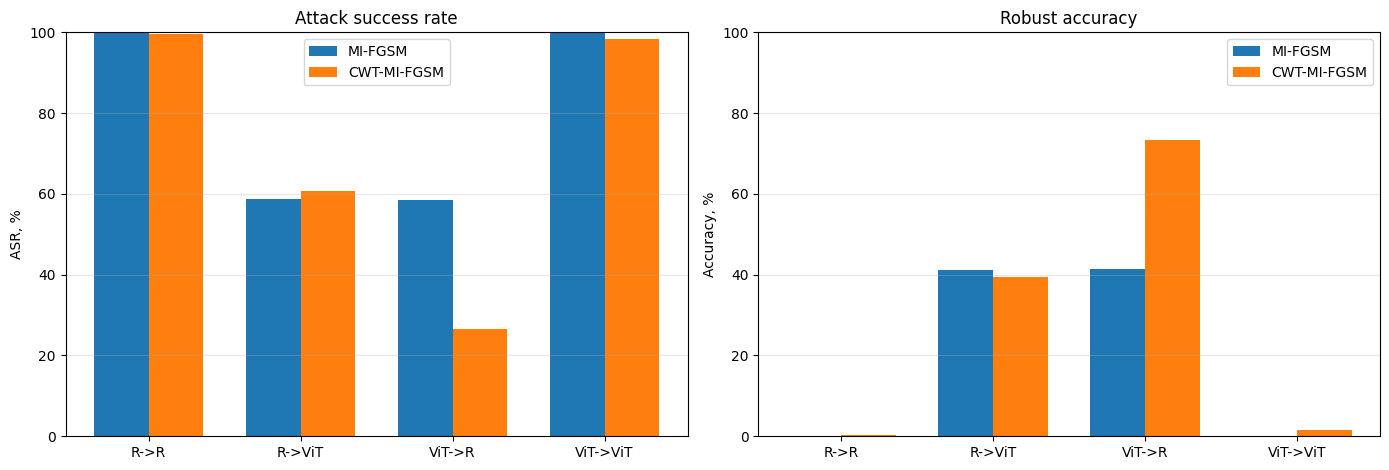

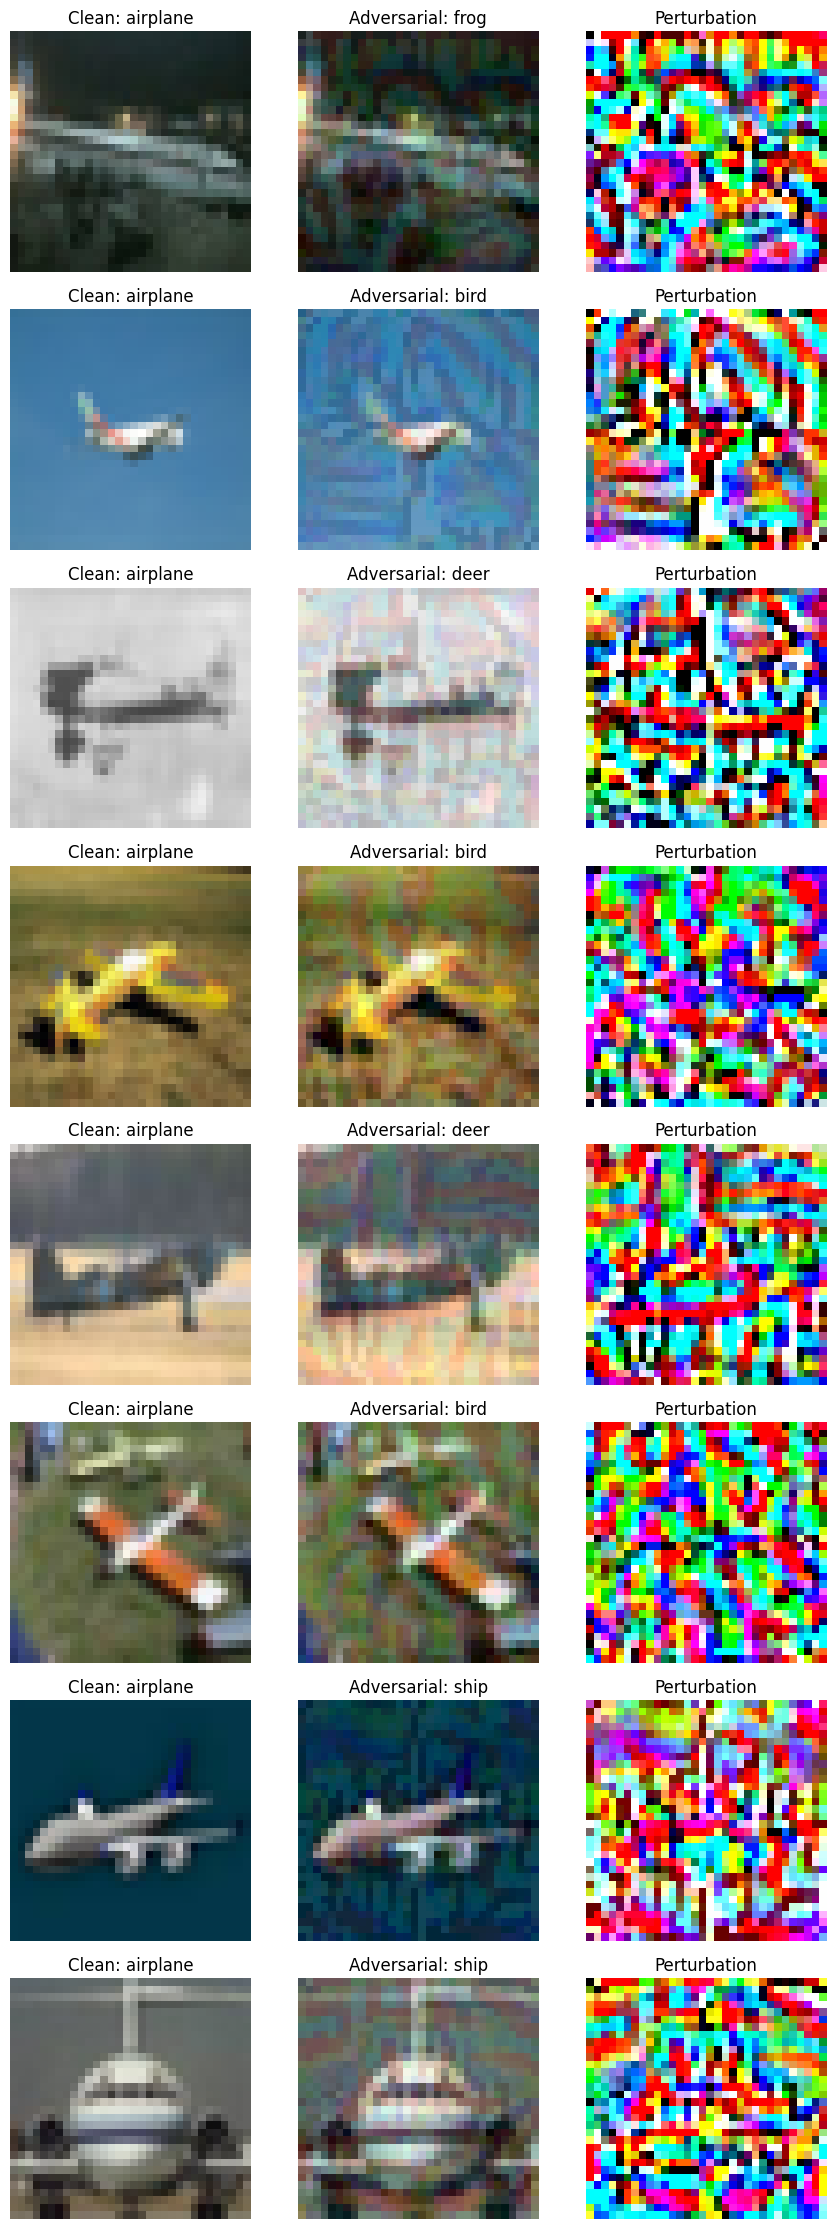

In [10]:
summary_df = (
    results_df.groupby(['surrogate', 'target', 'attack'], as_index=False)
    .agg(
        samples=('success', 'size'),
        attack_success_rate=('success', 'mean'),
        mean_surrogate_evaluations=('surrogate_evaluations', 'mean'),
    )
)
summary_df['robust_accuracy'] = 1.0 - summary_df['attack_success_rate']
summary_df.to_csv(OUTPUT_DIR / 'cwt_summary.csv', index=False)
display(summary_df.style.format({
    'attack_success_rate': '{:.2%}',
    'robust_accuracy': '{:.2%}',
    'mean_surrogate_evaluations': '{:.1f}',
}))

summary_df['direction'] = summary_df['surrogate'] + ' -> ' + summary_df['target']
directions = [
    'resnet18 -> resnet18', 'resnet18 -> vit_tiny',
    'vit_tiny -> resnet18', 'vit_tiny -> vit_tiny',
]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(directions))
for offset, attack_name in zip((-0.18, 0.18), ('MI-FGSM', 'CWT-MI-FGSM')):
    ordered = summary_df[summary_df['attack'] == attack_name].set_index('direction').loc[directions]
    axes[0].bar(x + offset, ordered['attack_success_rate'] * 100, width=0.36, label=attack_name)
    axes[1].bar(x + offset, ordered['robust_accuracy'] * 100, width=0.36, label=attack_name)
for axis, title, ylabel in zip(
    axes, ('Attack success rate', 'Robust accuracy'), ('ASR, %', 'Accuracy, %')
):
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.set_xticks(x, ['R->R', 'R->ViT', 'ViT->R', 'ViT->ViT'])
    axis.set_ylim(0, 100)
    axis.grid(axis='y', alpha=0.3)
    axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'cwt_transferability.png', dpi=160, bbox_inches='tight')
plt.show()

if example_records:
    fig, axes = plt.subplots(len(example_records), 3, figsize=(9, 2.8 * len(example_records)), squeeze=False)
    for row, example in enumerate(example_records):
        clean = example['clean'].permute(1, 2, 0).numpy()
        adversarial = example['adversarial'].permute(1, 2, 0).numpy()
        perturbation = np.clip((adversarial - clean) / (2 * EPSILON) + 0.5, 0, 1)
        axes[row, 0].imshow(clean)
        axes[row, 1].imshow(adversarial)
        axes[row, 2].imshow(perturbation)
        axes[row, 0].set_title(f"Clean: {CIFAR10_CLASSES[example['label']]}")
        axes[row, 1].set_title(f"Adversarial: {CIFAR10_CLASSES[example['prediction']]}")
        axes[row, 2].set_title('Perturbation')
        axes[row, 0].set_ylabel(f"{example['surrogate']} -> {example['target']}")
        for axis in axes[row]:
            axis.axis('off')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'cwt_transfer_examples.png', dpi=160, bbox_inches='tight')
    plt.show()


## Final checks and saved outputs

In [11]:
fingerprints_after = {name: state_fingerprint(model) for name, model in models_by_name.items()}
assert fingerprints_after == fingerprints_before
assert all(parameter.grad is None for model in models_by_name.values() for parameter in model.parameters())
assert len(results_df) == MAX_SAMPLES * 2 * 2 * 2
assert results_df['success'].dtype == bool
assert set(summary_df['attack']) == {'MI-FGSM', 'CWT-MI-FGSM'}
configuration = {
    'seed': SEED, 'samples': MAX_SAMPLES, 'epsilon': EPSILON, 'steps': STEPS,
    'momentum_decay': MOMENTUM_DECAY, 'cwt': CWTConfig(copies=CWT_COPIES).__dict__,
    'copy_chunk': COPY_CHUNK, 'elapsed_seconds': elapsed_seconds,
}
with (OUTPUT_DIR / 'cwt_configuration.json').open('w', encoding='utf-8') as file:
    json.dump(configuration, file, indent=2)
for required in (
    OUTPUT_DIR / 'cwt_detailed_results.csv',
    OUTPUT_DIR / 'cwt_summary.csv',
    OUTPUT_DIR / 'cwt_transferability.png',
    OUTPUT_DIR / 'cwt_configuration.json',
):
    assert required.is_file(), required
print('Saved outputs:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(' ', path)


Saved outputs:
  /kaggle/working/cwt_transferability/cwt_configuration.json
  /kaggle/working/cwt_transferability/cwt_detailed_results.csv
  /kaggle/working/cwt_transferability/cwt_summary.csv
  /kaggle/working/cwt_transferability/cwt_transfer_examples.png
  /kaggle/working/cwt_transferability/cwt_transferability.png
